# OPTIMISATION DE PORTEFEUILLE AJUSTÉE À L'ESG EN PÉRIODE DE CHOC : UN SYSTÈME D'AIDE À LA DÉCISION BASÉ SUR LE TRAITEMENT DU LANGAGE NATUREL
---

**Galatasaray Üniversitesi — Endüstri Mühendisliği Bitirme Projesi (IND 498)**  
**Öğrenciler:** Melike İklim Bulut & Arda Demirci  
**Danışman:** Prof. Dr. Saadettin Emre Alptekin  
**Dönem:** Mayıs 2026

---

> *"Les scores de risque ESG — décomposés en leurs sous-dimensions Environnementale (E), Sociale (S) et de Gouvernance (G) — modèrent-ils l'effet des chocs de sentiment médiatique négatif sur les rendements boursiers et la volatilité des actions cotées au S&P 500 ? Dans quelle mesure les coefficients de modération estimés peuvent-ils être intégrés dans une matrice de variance-covariance ajustée afin de construire un portefeuille à variance minimale plus résilient aux chocs informationnels?"*

---

# 1. Giriş / Introduction

## 1.1 Araştırma Sorusu ve Motivasyon

Bu çalışma, **ESG (Çevresel, Sosyal ve Yönetişim) risk skorlarının**, finansal medyada gözlemlenen **negatif sentiment şoklarının** hisse senedi getirileri ve volatilitesi üzerindeki etkisini **modere edip etmediğini** araştırmaktadır.

Literatürde ESG'nin firma performansına etkisi tartışılmış olsa da, şu soruya yanıt veren çalışma sayısı sınırlıdır:  
> *Sürdürülebilirlik profili zayıf olan firmalar, kötü haberlere (sentiment şoklarına) karşı daha mı kırılgan?*

## 1.2 Veri Seti Genel Görünümü

| Boyut | Değer |
|---|---|
| Şirket sayısı | 12 (S&P 500'den seçildi) |
| Sektör sayısı | 4 (Technology, Finance, Healthcare, Energy) |
| Zaman aralığı | 2023 (250 iş günü) |
| Toplam haber | 11.877 |
| Negatif şok sayısı | 131 (%4,37) |
| Kullanılan NLP Modeli | ProsusAI/FinBERT |

**Şirketler ve ESG Seviyeleri:**

| Sektör | Yüksek ESG Riski | Orta ESG Riski | Düşük ESG Riski |
|---|---|---|---|
| Technology | MCHP | VRSN | NVDA |
| Energy | COP | OKE | KMI |
| Healthcare | UHS | LLY | UNH |
| Financial | WFC | GS | V |

## 1.3 Ekonometrik Model

Çalışmanın ana regresyon modeli iki-yönlü sabit etkiler (Two-Way Fixed Effects) panel modelidir:

$$Y_{it} = \alpha + \beta_1 \cdot \text{Shock}_{it} + \beta_2 \cdot (\text{Shock}_{it} \times \text{ESG}_i) + \beta_3 \cdot \log(\text{news})_{it} + \mu_i + \lambda_t + \varepsilon_{it}$$

- $Y_{it}$: Bağımlı değişken — log getiri veya gerçekleşmiş volatilite
- $\beta_1$: Şokun doğrudan etkisi (H1)
- $\beta_2$: ESG'nin moderatör etkisi (H2 — ana hipotez)
- $\mu_i$: Firma sabit etkisi; $\lambda_t$: Zaman sabit etkisi

# 2. Ortam Hazırlığı ve Kurulum

Tez Google Colab (T4 GPU) ortamında çalışacak şekilde tasarlanmıştır.  

In [ ]:
# Kütüphanelerin yüklenmesi
!pip install linearmodels --quiet
!pip install transformers torch --quiet

import os
import sys
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings('ignore')

print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.8 MB/s eta 0:00:00
  pandas  : 2.2.2
  numpy   : 2.0.2



# FİNANSAL GETİRİ VE VOLATİLİTE VERİLERİNİN HAZIRLIĞI

Colab ortamında yfinance kütüphanesi kullanılarak 1 -3 -5 -10 günlük finansal getirilerin ve volatilitenin çekilmesi

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from google.colab import files

#Şirket Listesi
tickers = ['MCHP', 'NVDA', 'VRSN', 'COP', 'KMI', 'OKE', 'LLY', 'UNH', 'UHS', 'V', 'GS', 'WFC']

print("Veriler Yahoo Finance üzerinden çekiliyor...")
raw_data = yf.download(tickers, start="2022-12-15", end="2023-12-31")['Close']

#Getiri hesabı
prices = raw_data.loc['2023-01-01':]
ret1 = raw_data.pct_change(1).loc['2023-01-01':]
ret3 = raw_data.pct_change(3).loc['2023-01-01':]
ret5 = raw_data.pct_change(5).loc['2023-01-01':]
ret10 = raw_data.pct_change(10).loc['2023-01-01':]
vol = raw_data.pct_change(1).rolling(window=10).std().loc['2023-01-01':]

#Panel formatına hazır hale getirme
def make_long(df, name):
    return df.stack().reset_index().rename(columns={'level_1': 'Ticker', 0: name, 'Date': 'Tarih'})

df_prices = make_long(prices, 'Price')
df_ret1 = make_long(ret1, 'Return_1d')
df_ret3 = make_long(ret3, 'Return_3d')
df_ret5 = make_long(ret5, 'Return_5d')
df_ret10 = make_long(ret10, 'Return_10d')
df_vol = make_long(vol, 'Volatility_Daily')

final_financials = df_prices.merge(df_ret1, on=['Tarih', 'Ticker']) \
                             .merge(df_ret3, on=['Tarih', 'Ticker']) \
                             .merge(df_ret5, on=['Tarih', 'Ticker']) \
                             .merge(df_ret10, on=['Tarih', 'Ticker']) \
                             .merge(df_vol, on=['Tarih', 'Ticker'])

final_financials = final_financials[['Tarih', 'Ticker', 'Price', 'Return_1d', 'Return_3d', 'Return_5d', 'Return_10d', 'Volatility_Daily']]

metrics = {
    'PRICES_2023.csv': prices,
    'RETURN_1D_2023.csv': ret1,
    'RETURN_3D_2023.csv': ret3,
    'RETURN_5D_2023.csv': ret5,
    'RETURN_10D_2023.csv': ret10,
    'VOLATILITY_DAILY_2023.csv': vol
}

for file_name, df in metrics.items():
    df.to_csv(file_name)
    files.download(file_name)

Veriler Yahoo Finance üzerinden çekiliyor...


[*********************100%***********************]  12 of 12 completed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

DATA_DIR = Path("/content")

# Input files
F_RAW_NEWS  = DATA_DIR / "verisetbirles_ikson.xlsx"
F_SENTIMENT = DATA_DIR / "FinBERT_Sentiment_Panel.xlsx"
F_RET_1D    = DATA_DIR / "RETURN_1D_2023.csv"
F_RET_3D    = DATA_DIR / "RETURN_3D_2023.csv"
F_RET_5D    = DATA_DIR / "RETURN_5D_2023.csv"
F_RET_10D   = DATA_DIR / "RETURN_10D_2023.csv"
F_VOL       = DATA_DIR / "VOLATILITY_DAILY_2023.csv"
F_ESG       = DATA_DIR / "/content/esgsriskcores2023.csv"
F_PANEL_VIZ = DATA_DIR / "final_panel_2023_formatted (2).xlsx"

# Output files
OUT_FINBERT = DATA_DIR / "FinBERT_Sentiment_Panel_2023.xlsx"
OUT_PANEL   = DATA_DIR / "final_panel_2023.xlsx"
OUT_RESULTS = DATA_DIR / "regression_results.xlsx"

os.makedirs('figures', exist_ok=True)

print("Dosya varlık kontrolü:")
all_inputs = [F_RAW_NEWS, F_SENTIMENT, F_RET_1D, F_RET_3D, F_RET_5D,
              F_RET_10D, F_VOL, F_ESG, F_PANEL_VIZ]
for f in all_inputs:
    status = "yüklenmiş" if f.exists() else "EKSİK"
    print(f"  {status}  {f.name}")

Dosya varlık kontrolü:
  yüklenmiş  verisetbirles_ikson.xlsx
  yüklenmiş  FinBERT_Sentiment_Panel.xlsx
  yüklenmiş  RETURN_1D_2023.csv
  yüklenmiş  RETURN_3D_2023.csv
  yüklenmiş  RETURN_5D_2023.csv
  yüklenmiş  RETURN_10D_2023.csv
  yüklenmiş  VOLATILITY_DAILY_2023.csv
  yüklenmiş  esgsriskcores2023.csv
  yüklenmiş  final_panel_2023_formatted (2).xlsx


# 3. Veri Hazırlığı / Préparation des Données

## 3.1 Haber Verisi Yükleme

Ham veri seti `verisetbirles_ikson.xlsx` dosyasında yer almaktadır. Bu dosya üç farklı kaynaktan birleştirilmiştir:
- **AlphaVantage** — finansal haber API'si
- **Marketaux** — ticker bazlı haber verisi  
- **Kaggle (Financial News with Sentiment)** — etiketlenmiş finansal haberler

Sadece `news_type == 'company'` ve geçerli `ticker` eşleşmesi olan haberler analize dahil edilmektedir.

In [ ]:
# Haber Verilerinin yüklenmesi
def load_data(input_file):
    df = pd.read_excel(input_file)
    df['date'] = pd.to_datetime(df['date'])

    # Ticker bazlı eleme
    company_df = df[
        df['ticker'].notna() & (df['news_type'] == 'company')
    ].copy()
    company_df = company_df.sort_values(['ticker', 'date']).reset_index(drop=True)

    print(f"  Toplam haber : {len(company_df):,}")
    print(f"  Şirket sayısı: {company_df['ticker'].nunique()}")
    print(f"  Dönem        : {company_df['date'].min().date()} → {company_df['date'].max().date()}")
    return company_df

company_df = load_data(F_RAW_NEWS)
company_df[['date', 'ticker', 'title', 'source']].head(5)

  Toplam haber : 11,877
  Şirket sayısı: 12
  Dönem        : 2023-01-01 → 2023-12-30


,date,ticker,title,source
0,2023-01-03,COP,Will ConocoPhillips (COP) Beat Estimates Again...,Nasdaq
1,2023-01-03,COP,How to Find Strong Oils and Energy Stocks Slat...,Nasdaq
2,2023-01-04,COP,Midway announces redevelopment of ConocoPhilli...,The Architect’s Newspaper
3,2023-01-04,COP,Canada oil sands producers to begin evaluating...,Nasdaq
4,2023-01-04,COP,"Notable Wednesday Option Activity: AAL, COP, EQT",Nasdaq


## 3.2 FinBERT ile Sentiment Analizi

**FinBERT** (ProsusAI/finbert), finansal metinler üzerinde fine-tune edilmiş bir BERT modelidir. Genel amaçlı dil modellerine kıyasla finansal terminolojiyi çok daha iyi kavrar ve bu sebeple seçilmiştir.

Her haber için model şu çıktıları üretecektir:
- **Label**: `positive` / `negative` / `neutral`
- **Confidence score**: Modelin tahminine olan güveni (0–1 arası)

**Polarite Skoru** aşağıdaki formülle hesaplanmıştır:

$$\text{polarity}_{it} = \begin{cases} +\text{confidence} & \text{eğer pozitif} \\ -\text{confidence} & \text{eğer negatif} \\ 0 & \text{eğer nötr} \end{cases}$$

In [ ]:
# FinBERT pipeline konfigürasyonu
CACHE_FILE           = "finbert_cache.csv"
ROLLING_WINDOW       = 30    # days for rolling z-score
ZSCORE_THRESHOLD     = -1.5  # shock detection threshold
PERCENTILE_THRESHOLD = 10    # bottom percentile cutoff
BATCH_SIZE           = 32    # GPU batch size
USE_FINBERT          = True  # set False to use lexicon fallback

# Loughran-McDonald financial lexicon
POSITIVE_WORDS = {
    'record', 'beat', 'beats', 'exceeded', 'growth', 'profit', 'profitable',
    'revenue', 'gains', 'surge', 'surged', 'rally', 'strong', 'upgrade',
    'upgraded', 'outperform', 'bullish', 'expansion', 'breakthrough',
    'dividend', 'buyback', 'approved', 'launch', 'increase', 'improvement',
    'momentum', 'milestone', 'success', 'robust', 'solid', 'win', 'recovery'
}
NEGATIVE_WORDS = {
    'loss', 'losses', 'decline', 'declined', 'decrease', 'miss', 'missed',
    'shortfall', 'deficit', 'debt', 'lawsuit', 'investigation', 'fine',
    'layoff', 'restructuring', 'bankruptcy', 'default', 'downgrade',
    'concern', 'uncertainty', 'slump', 'crash', 'fraud', 'scandal',
    'warning', 'disappointing', 'weak', 'challenging', 'failed', 'crisis'
}

print("✓ FinBERT konfigürasyonu ayarlandı.")
print(f"  Rolling pencere : {ROLLING_WINDOW} gün")
print(f"  Z-score eşiği   : {ZSCORE_THRESHOLD}")
print(f"  Percentile      : Alt {PERCENTILE_THRESHOLD}. yüzdelik")

✓ FinBERT konfigürasyonu ayarlandı.
  Rolling pencere : 30 gün
  Z-score eşiği   : -1.5
  Percentile      : Alt 10. yüzdelik


In [ ]:
def run_finbert(texts, batch_size=BATCH_SIZE):
    """Run ProsusAI/finbert on a list of text strings."""
    from transformers import pipeline
    import torch

    device = 0 if torch.cuda.is_available() else -1
    print(f"  Model yükleniyor... ({'GPU' if device == 0 else 'CPU'})")

    clf = pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        return_all_scores=False,
        device=device,
        truncation=True,
        max_length=512
    )

    results = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t)[:512] for t in texts[i:i + batch_size]]
        out = clf(batch)
        for o in out:
            results.append({'label': o['label'].lower(), 'score': round(float(o['score']), 4)})
        if (i + batch_size) % 1000 == 0:
            print(f"  {min(i + batch_size, len(texts)):,} / {len(texts):,} haber işlendi")
    return results


def run_lexikon(texts):
    """Loughran-McDonald sözlük tabanlı duygu puanlayıcısı"""
    results = []
    for text in texts:
        words = str(text).lower().split()
        pos = sum(1 for w in words if w in POSITIVE_WORDS)
        neg = sum(1 for w in words if w in NEGATIVE_WORDS)
        total = pos + neg
        if total == 0:
            results.append({'label': 'neutral', 'score': 0.60})
        else:
            conf = round(0.55 + 0.40 * (max(pos, neg) / total), 4)
            if pos > neg:
                results.append({'label': 'positive', 'score': conf})
            elif neg > pos:
                results.append({'label': 'negative', 'score': conf})
            else:
                results.append({'label': 'neutral', 'score': 0.60})
    return results


def hesapla_sentiment(company_df):
    print("\nFinBERT sentiment analizi başlıyor...")

    if os.path.exists(CACHE_FILE):
        cache = pd.read_csv(CACHE_FILE)
        if len(cache) == len(company_df):
            print(f"  Cache bulundu → yeniden hesaplamadan yükleniyor ({CACHE_FILE})")
            company_df['finbert_label'] = cache['finbert_label'].values
            company_df['finbert_score'] = cache['finbert_score'].values
            print(f"  Dağılım: {company_df['finbert_label'].value_counts().to_dict()}")
            return company_df
        else:
            print("  Cache boyutu uyuşmuyor ")

    texts = (company_df['text'].fillna('') + ' ' + company_df['title'].fillna('')).tolist()

    if USE_FINBERT:
        try:
            results = run_finbert(texts)
        except Exception as e:
            print(f"  FinBERT yüklenemedi: {e}\n  → Lexikon yöntemine geçiliyor...")
            results = run_lexikon(texts)
    else:
        results = run_lexikon(texts)

    company_df['finbert_label'] = [r['label'] for r in results]
    company_df['finbert_score'] = [r['score'] for r in results]
    company_df[['finbert_label', 'finbert_score']].to_csv(CACHE_FILE, index=False)
    print(f"  Cache kaydedildi: {CACHE_FILE}")
    print(f"  Dağılım: {company_df['finbert_label'].value_counts().to_dict()}")
    return company_df


company_df = hesapla_sentiment(company_df)


FinBERT sentiment analizi başlıyor...
  Cache bulundu → yeniden hesaplamadan yükleniyor (finbert_cache.csv)
  Dağılım: {'neutral': 4422, 'positive': 4170, 'negative': 3285}


## 3.3 Günlük Agregasyon ve Şok Tespiti

### Günlük Agregasyon
Her `(ticker, gün)` çifti için birden fazla haber bulunabilir bu sebeple Haberleri günlük düzeye indirmek gereklidir:
- **Ortalama polarite** hesaplanır (tüm haber polaritelerinin ortalaması)
- **Negatif oran** hesaplanır: $\text{neg\_ratio} = n_{\text{neg}} / n_{\text{total}}$

### Şok Tespiti: İki Koşullu Yaklaşım

Bir günün negatif sentiment şoku olarak etiketlenmesi için **her iki koşulun aynı anda** sağlanması gerekmektedir:

**Koşul 1 — Z-Score Eşiği:**
$$z_{it} = \frac{\bar{p}_{it} - \mu_{i,30g}}{\sigma_{i,30g} + \epsilon} < -1.5$$

**Koşul 2 — Percentile Eşiği:**
$$\bar{p}_{it} < P_{10}(\text{ticker}_i)$$

Bu çift-koşullu yaklaşım, yalnızca z-score ya da yalnızca percentile kullanmaya kıyasla daha güvenilir ve anlamlı şok tespiti sağlayacaktır.

In [ ]:
def gunluk_agregasyon(company_df):

    def polarite(row):
        if row['finbert_label'] == 'positive':
            return row['finbert_score']
        elif row['finbert_label'] == 'negative':
            return -row['finbert_score']
        return 0.0

    company_df['polarity_score'] = company_df.apply(polarite, axis=1)

    daily = company_df.groupby(['ticker', 'date']).agg(
        n_news       =('polarity_score', 'count'),
        avg_polarity =('polarity_score', 'mean'),
        n_positive   =('finbert_label', lambda x: (x == 'positive').sum()),
        n_negative   =('finbert_label', lambda x: (x == 'negative').sum()),
        n_neutral    =('finbert_label', lambda x: (x == 'neutral').sum()),
        avg_conf     =('finbert_score', 'mean'),
    ).reset_index()

    daily['neg_ratio'] = daily['n_negative'] / daily['n_news']

    # Sector lookup
    if 'sector' in company_df.columns:
        sector_map = company_df.groupby('ticker')['sector'].first()
        daily['sector'] = daily['ticker'].map(sector_map)

    print(f"  Günlük panel: {daily.shape} — {daily['ticker'].nunique()} firma")
    return company_df, daily


def sok_tespiti(daily):
    epsilon = 1e-8

    daily = daily.sort_values(['ticker', 'date']).copy()

    # Koşul 1 : Rolling z-score
    daily['rolling_mean'] = (
        daily.groupby('ticker')['avg_polarity']
        .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=5).mean())
    )
    daily['rolling_std'] = (
        daily.groupby('ticker')['avg_polarity']
        .transform(lambda x: x.rolling(ROLLING_WINDOW, min_periods=5).std())
    )
    daily['rolling_zscore'] = (
        (daily['avg_polarity'] - daily['rolling_mean']) /
        (daily['rolling_std'] + epsilon)
    )
    daily['shock_zscore'] = (daily['rolling_zscore'] < ZSCORE_THRESHOLD).astype(int)

    # Koşul 2: Firm-specific percentile
    pct_threshold = daily.groupby('ticker')['avg_polarity'].transform(
        lambda x: x.quantile(PERCENTILE_THRESHOLD / 100)
    )
    daily['shock_pct'] = (daily['avg_polarity'] < pct_threshold).astype(int)

    # Combined shock: 2 koşulu sağlayan şoklar
    daily['sentiment_shock'] = (
        (daily['shock_zscore'] == 1) & (daily['shock_pct'] == 1)
    ).astype(int)

    # Şok yoğunluğu = |z-score| 'u şok günlerinde
    daily['shock_intensity'] = np.where(
        daily['sentiment_shock'] == 1,
        daily['rolling_zscore'].abs(),
        0.0
    )

    n_shocks = daily['sentiment_shock'].sum()
    pct = n_shocks / len(daily) * 100
    print(f"  Toplam şok: {n_shocks} ({pct:.2f}% gözlem)")
    print(f"  Firma başına şok dağılımı:")
    print(daily.groupby('ticker')['sentiment_shock'].sum().to_string())
    return daily


company_df, daily = gunluk_agregasyon(company_df)
daily = sok_tespiti(daily)

  Günlük panel: (2119, 10) — 12 firma
  Toplam şok: 133 (6.28% gözlem)
  Firma başına şok dağılımı:
ticker
COP     21
GS      18
KMI      1
LLY      6
MCHP     1
NVDA    19
OKE     15
UHS      6
UNH      4
V       20
VRSN     4
WFC     18


# 4. Final Panelinin Oluşturması

## 4.1 Haftasonu Haberleri → İş Günü Kaydırma

Borsalar yalnızca iş günleri açıktır. Hafta sonu veya tatil günlerinde yayımlanan haberler, **bir sonraki iş günündeki** fiyat hareketini etkiler. Bu nedenle, takvim bazlı sentiment verisini borsa takvimine eşlenecektir.

**Stratejimiz ise:** `pd.merge_asof(direction='forward')` ile her takvim günü, ondan büyük veya eşit olan **ilk borsa gününe** eşlemek olacaktır.

## 4.2 Finansal Değişkenleri Birleştirme

Paneli şu adımlarla oluşturduk:
1. Returns (1d/3d/5d/10d) geniş formattan uzun formata çevrildi
2. Günlük volatilite eklendi
3. Sentiment (trading-day bazlı) ile sol birleştirme (left join)
4. ESG skoru ticker bazında eklendi (zamansal boyut yok — firma-sabit)

In [ ]:
# (FinBERT_Sentiment_Panel.xlsx) hali hazırda oluşturulmuş sentiment skorları panelinin yüklenmesi
sent = pd.read_excel(F_SENTIMENT, sheet_name="Panel Verisi")
sent["Tarih"] = pd.to_datetime(sent["Tarih"])

# Sütun isimlerinin standardizasyonu
sent = sent.rename(columns={
    "Tarih": "date",
    "Ticker": "ticker",
    "Haber Sayısı": "news_count",
    "Ort. Polarite": "polarity_mean",
    "Ort. Güven": "confidence_mean",
    "Neg. Oran": "neg_ratio",
    "Rolling Z-Score": "rolling_z",
    "Şok(Z)": "shock_z",
    "Şok(Pct)": "shock_pct",
    "Sentiment Şoku": "shock",
    "Şok Yoğunluğu": "shock_intensity",
    "Pozitif": "n_positive",
    "Negatif": "n_negative",
    "Nötr": "n_neutral",
    "Sektör": "sector_tr",
})

print(f"Sentiment panel: {sent.shape}")
print(f"Toplam şok (takvim günü dahil): {int(sent['shock'].sum())}")

Sentiment panel: (2119, 15)
Toplam şok (takvim günü dahil): 133


In [ ]:
# Haftasonu ve tatil günlerini kaydırma
trading_dates = pd.read_csv(F_RET_1D)["Date"]
trading_dates = pd.to_datetime(trading_dates).sort_values().reset_index(drop=True)

print(f"2023 borsa açık gün sayısı: {len(trading_dates)}")
print(f"İlk gün: {trading_dates.iloc[0].date()}   Son gün: {trading_dates.iloc[-1].date()}")

calendar_all = pd.DataFrame({
    "calendar_date": pd.date_range(sent["date"].min(), sent["date"].max(), freq="D")
})
calendar_all = pd.merge_asof(
    calendar_all.sort_values("calendar_date"),
    pd.DataFrame({"trading_date": trading_dates}).sort_values("trading_date"),
    left_on="calendar_date",
    right_on="trading_date",
    direction="forward",
)

sent = sent.merge(
    calendar_all.rename(columns={"calendar_date": "date"}),
    on="date", how="left"
)

unmatched = sent["trading_date"].isna().sum()
print(f"Eşleşmeyen takvim satırı: {unmatched} (yıl sonu geçişi — analizden çıkarılacak)")

2023 borsa açık gün sayısı: 250
İlk gün: 2023-01-03   Son gün: 2023-12-29
Eşleşmeyen takvim satırı: 1 (yıl sonu geçişi — analizden çıkarılacak)


In [ ]:
# İşlem gününe göre genel duygu durumu seviyesi
sent_tdy = sent.dropna(subset=["trading_date"]).copy()

def weighted_mean(values, weights):
    """Haber sayısına göre ağırlıklı ortalama, sıfır ağırlıklı satırlar dikkate alınmadan hesaplanmıştır."""
    mask = (~pd.isna(values)) & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

grp = sent_tdy.groupby(["ticker", "trading_date"], as_index=False)

agg = grp.agg(
    news_count      =("news_count", "sum"),
    n_positive      =("n_positive", "sum"),
    n_negative      =("n_negative", "sum"),
    n_neutral       =("n_neutral", "sum"),
    shock           =("shock", "max"),   # shock = 1 eğer herhangi bir kaynak gününde şok yaşandıysa
    shock_intensity =("shock_intensity", "max"),
)

wavg = sent_tdy.groupby(["ticker", "trading_date"]).apply(
    lambda g: pd.Series({
        "polarity_mean":   weighted_mean(g["polarity_mean"].values, g["news_count"].values),
        "confidence_mean": weighted_mean(g["confidence_mean"].values, g["news_count"].values),
        "neg_ratio":       weighted_mean(g["neg_ratio"].values, g["news_count"].values),
        "rolling_z":       weighted_mean(g["rolling_z"].values, g["news_count"].values),
    }),
    include_groups=False,
).reset_index()

sent_daily = agg.merge(wavg, on=["ticker", "trading_date"]).rename(columns={"trading_date": "date"})
print(f"Trading-day sentiment paneli: {sent_daily.shape}")
print(f"İş günü bazlı toplam şok: {int(sent_daily['shock'].sum())}")

Trading-day sentiment paneli: (1744, 12)
İş günü bazlı toplam şok: 131


In [ ]:
# Geniş formatlı getirileri uzun formata dönüştürme ve son birleştirme.
def wide_to_long(filepath, value_name):
    """Pivot wide return/volatility tables to (date, ticker, value) format."""
    df = pd.read_csv(filepath)
    df = df.rename(columns={df.columns[0]: "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.melt(id_vars="date", var_name="ticker", value_name=value_name)
    df["ticker"] = df["ticker"].str.strip()
    return df.dropna(subset=[value_name])

ret_1d  = wide_to_long(F_RET_1D,  "return_1d")
ret_3d  = wide_to_long(F_RET_3D,  "return_3d")
ret_5d  = wide_to_long(F_RET_5D,  "return_5d")
ret_10d = wide_to_long(F_RET_10D, "return_10d")
vol_d   = wide_to_long(F_VOL,     "volatility")

# Tüm finansal değişkenleri birleştirme
financial = ret_1d
for df_next in [ret_3d, ret_5d, ret_10d, vol_d]:
    financial = financial.merge(df_next, on=["date", "ticker"], how="outer")

print(f"Finansal panel: {financial.shape}")

Finansal panel: (3000, 7)


In [ ]:
# ESG Risk Skorlarının yüklenmesi
esg = pd.read_csv(F_ESG, sep=';', header=1, on_bad_lines='skip')
print(esg.columns)
esg = esg.rename(columns={
    "Symbol": "ticker",
    "Name": "company_name",
    "Sector": "sector_en",
    "Total ESG Risk Score": "esg_total",
    "Environment Risk Score": "esg_e",
    "Governance Risk Score": "esg_g",
    "Social Risk Score": "esg_s",
    "Controversy Level": "controversy_level",
    "Controversy Score": "controversy_score",
    "ESG Risk Percentile": "esg_percentile",
    "ESG Risk Level": "esg_level",
})

sector_map_fr = {
    "Technology": "Technologie",
    "Financial Services": "Finance",
    "Healthcare": "Santé",
    "Energy": "Énergie",
}
esg["sector_fr"] = esg["sector_en"].map(sector_map_fr)

esg_cols = ["ticker", "company_name", "sector_en", "sector_fr",
            "esg_total", "esg_e", "esg_s", "esg_g",
            "controversy_level", "controversy_score", "esg_percentile", "esg_level"]
esg = esg[esg_cols]

print(f"ESG tablosu: {esg.shape}")
esg[["ticker", "sector_en", "esg_total", "esg_e", "esg_s", "esg_g", "esg_level"]]

Index(['Symbol', 'Name', 'Address', 'Sector', 'Total ESG Risk score',
       'Environment Risk Score', 'Governance Risk Score', 'Social Risk Score',
       'Controversy Level', 'Controversy Score', 'ESG Risk Percentile',
       'ESG Risk Level'],
      dtype='object')
ESG tablosu: (12, 12)


,ticker,sector_en,esg_total,esg_e,esg_s,esg_g,esg_level
0,MCHP,Technology,31.8,15.3,9.2,7.4,High
1,NVDA,Technology,13.6,2.3,4.9,6.3,Low
2,VRSN,Technology,21.3,4.7,10.8,5.8,Medium
3,COP,Energy,33.9,17.6,8.1,8.3,High
4,KMI,Energy,19.0,8.3,7.2,3.5,Low
5,OKE,Energy,25.1,10.8,11.0,3.3,Medium
6,LLY,Healthcare,24.3,2.5,12.6,9.1,Medium
7,UNH,Healthcare,15.3,0.0,9.7,5.6,Low
8,UHS,Healthcare,33.0,3.7,20.7,8.6,High
9,V,Financial Services,16.7,1.8,8.2,6.7,Low


In [ ]:
# Final Panelinin oluşturulması: financial ← sentiment (solda) ← ESG (solda)
panel = financial.merge(sent_daily, on=["date", "ticker"], how="left")

# Eksik şok göstergelerinin 0 ile doldurulması (haber yok, şok da yok).
zero_fill_cols = ["shock", "news_count", "n_positive", "n_negative",
                  "n_neutral", "shock_intensity"]
for c in zero_fill_cols:
    if c in panel.columns:
        panel[c] = panel[c].fillna(0)

# ESG eklnmesi (firm-level, time-invariant)
panel = panel.merge(esg, on="ticker", how="left")
panel = panel.sort_values(["ticker", "date"]).reset_index(drop=True)

# Panel ID
panel["firm_id"] = panel["ticker"].astype("category").cat.codes
panel["t_id"]    = panel["date"].rank(method="dense").astype(int)

print(f"\n{'='*60}")
print(f"FINAL PANEL: {panel.shape[0]:,} satır × {panel.shape[1]} sütun")
print(f"Beklenen: 250 iş günü × 12 şirket = 3,000 satır")
print(f"\nKalite Kontrolleri:")
days_per_firm = panel.groupby('ticker')['date'].nunique()
print(f"  Dengeli panel: {days_per_firm.nunique() == 1}")
print(f"  Toplam şok (iş günü): {int(panel['shock'].sum())}")
print(f"\nEksik değerler (ana değişkenler):")
key_cols = ["return_1d", "return_3d", "return_5d", "return_10d",
            "volatility", "shock", "esg_total", "esg_e", "esg_s", "esg_g"]
print(panel[key_cols].isna().sum().to_string())

with pd.ExcelWriter(OUT_PANEL, engine="openpyxl") as w:
    panel.to_excel(w, sheet_name="Final Panel", index=False)
    esg.to_excel(w, sheet_name="ESG Scores", index=False)
print(f"\n✓ Final panel kaydedildi: {OUT_PANEL}")


FINAL PANEL: 3,000 satır × 30 sütun
Beklenen: 250 iş günü × 12 şirket = 3,000 satır

Kalite Kontrolleri:
  Dengeli panel: True
  Toplam şok (iş günü): 131

Eksik değerler (ana değişkenler):
return_1d     0
return_3d     0
return_5d     0
return_10d    0
volatility    0
shock         0
esg_total     0
esg_e         0
esg_s         0
esg_g         0

✓ Final panel kaydedildi: /content/final_panel_2023.xlsx


# 5. Metodoloji: İki-Yönlü Sabit Etkiler Panel Regresyonu

## 5.1 Model Spesifikasyonu

**Two-Way Fixed Effects (TWFE)** modeli, firma ve zaman boyutlarındaki gözlemlenemeyen heterojenliği aynı anda kontrol eder:

$$Y_{it} = \alpha + \underbrace{\beta_1 \cdot \text{Shock}_{it}}_{\text{doğrudan etki}} + \underbrace{\beta_2 \cdot (\text{Shock}_{it} \times \text{ESG}_i)}_{\text{moderatör etki}} + \beta_3 \cdot \log(\text{news}_{it}) + \mu_i + \lambda_t + \varepsilon_{it}$$

| Bileşen | Açıklaması |
|---|---|
| $\mu_i$ | Firma sabit etkisi (firma-spesifik sabit faktörleri absorbe etmesi için) |
| $\lambda_t$ | Zaman sabit etkisi ( tüm firmayı etkileyen makroekonomik faktörler) |
| $\varepsilon_{it}$ | Cluster-robust standart hata (firma düzeyinde) |

## 5.2 Uygulanan 8 Ana Model

| Model | Bağımlı değişken (Y) | ESG Bileşeni |
|---|---|---|
| M1 | return_1d | ESG Total |
| M2 | return_1d | ESG Environmental (E) |
| M3 | return_1d | ESG Social (S) |
| M4 | return_1d | ESG Governance (G) |
| M5 | volatility | ESG Total |
| M6 | volatility | ESG Environmental (E) |
| M7 | volatility | ESG Social (S) |
| M8 | volatility | ESG Governance (G) |

## 5.3 ESG Standardizasyonu

E, S, G bileşenleri farklı ölçeklerde olduğundan (E: 0–18, S: 5–21, G: 3–19, Total: 13–36), tüm ESG değişkenleri firma düzeyinde standardize edilmiştir:

$$\text{ESG}_i^z = \frac{\text{ESG}_i - \bar{\text{ESG}}}{\text{SD}(\text{ESG})}$$

Bu sayede $\beta_2$ katsayısı *"1 standart sapmalık ESG artışı başına moderatör etki"* olarak yorumlanabilmekle birlikte dört ayrı bileşen karşılaştırılabilir hale gelmektedir.

In [ ]:
from linearmodels.panel import PanelOLS

# Regresyon için panelin uüklenmesi
xl        = pd.ExcelFile(OUT_PANEL)
panel_reg = pd.read_excel(OUT_PANEL, sheet_name=xl.sheet_names[0])
panel_reg["date"] = pd.to_datetime(panel_reg["date"])

if "n_news" in panel_reg.columns and "news_count" not in panel_reg.columns:
    panel_reg = panel_reg.rename(columns={"n_news": "news_count"})

# Esg risk skorlarının stanzartize edilmesi
esg_components = ["esg_total", "esg_e", "esg_s", "esg_g"]
esg_firm = panel_reg.drop_duplicates("ticker")[["ticker"] + esg_components].copy()

for c in esg_components:
    mu, sd = esg_firm[c].mean(), esg_firm[c].std()
    esg_firm[f"{c}_z"] = (esg_firm[c] - mu) / sd

print("Standardize ESG (12 firma):")
print(esg_firm[["ticker"] + [f"{c}_z" for c in esg_components]].round(2).to_string(index=False))

panel_reg = panel_reg.merge(
    esg_firm[["ticker"] + [f"{c}_z" for c in esg_components]],
    on="ticker", how="left"
)

# İnteraksiyon: Shock × ESG_z
for comp in ["total", "e", "s", "g"]:
    panel_reg[f"shock_x_esg_{comp}"] = panel_reg["shock"] * panel_reg[f"esg_{comp}_z"]

# Logaritmik dönüşüm uygulanmış haber sayısı (right-skewed distributin)
panel_reg["log_news"] = np.log1p(panel_reg["news_count"])

# Lineer model için Çoklu İndeks Ayarı PanelOLS
panel_reg = panel_reg.set_index(["ticker", "date"]).sort_index()

print(f"\n✓ Panel regression için hazır: {panel_reg.shape}")

Standardize ESG (12 firma):
ticker  esg_total_z  esg_e_z  esg_s_z  esg_g_z
   COP         1.20     2.01    -0.66     0.07
    GS         0.11    -0.84     0.48     0.89
   KMI        -0.73     0.42    -0.88    -1.04
   LLY        -0.04    -0.57     0.43     0.26
  MCHP         0.93     1.62    -0.40    -0.14
  NVDA        -1.43    -0.60    -1.44    -0.39
   OKE         0.06     0.85     0.04    -1.09
   UHS         1.08    -0.36     2.39     0.14
   UNH        -1.21    -0.99    -0.27    -0.55
     V        -1.03    -0.69    -0.64    -0.30
  VRSN        -0.43    -0.19    -0.01    -0.51
   WFC         1.50    -0.65     0.96     2.65

✓ Panel regression için hazır: (3000, 37)


In [ ]:
def run_twoway_fe(data, y_col, esg_component):
    """
    Estimate Two-Way Fixed Effects panel regression.

    Parameters
    ----------
    data          : MultiIndex (ticker, date) DataFrame
    y_col         : dependent variable column name
    esg_component : 'total' | 'e' | 's' | 'g'

    Returns
    -------
    PanelEffectsResults with cluster-robust SE at firm level
    """
    interaction = f"shock_x_esg_{esg_component}"
    cols = [y_col, "shock", interaction, "log_news"]
    df   = data[cols].dropna()

    model = PanelOLS(
        dependent      = df[y_col],
        exog           = df[["shock", interaction, "log_news"]],
        entity_effects = True,
        time_effects   = True,
        drop_absorbed  = True,
    )
    return model.fit(cov_type="clustered", cluster_entity=True)


def result_row(res, label, esg_component):
    """Extract a summary dict from regression results."""
    interaction = f"shock_x_esg_{esg_component}"

    def fmt(coef, pval):
        stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
        return f"{coef:.5f}{stars}"

    return {
        "Model"        : label,
        "N"            : int(res.nobs),
        "R²_within"    : round(res.rsquared_within, 4),
        "β1_shock"     : fmt(res.params["shock"],       res.pvalues["shock"]),
        "β1_SE"        : f"({res.std_errors['shock']:.5f})",
        "β2_ShockxESG" : fmt(res.params[interaction],   res.pvalues[interaction]),
        "β2_SE"        : f"({res.std_errors[interaction]:.5f})",
        "β2_pvalue"    : round(res.pvalues[interaction], 4),
        "β2_sig"       : ("***" if res.pvalues[interaction] < 0.01 else
                          "**"  if res.pvalues[interaction] < 0.05 else
                          "*"   if res.pvalues[interaction] < 0.10 else ""),
    }


print("=" * 70)
print("PILOT: return_1d ~ shock + shock×ESG_total + log_news + FE")
print("=" * 70)
pilot = run_twoway_fe(panel_reg, "return_1d", "total")
print(pilot.summary)

PILOT: return_1d ~ shock + shock×ESG_total + log_news + FE
                          PanelOLS Estimation Summary                           
Dep. Variable:              return_1d   R-squared:                        0.0010
Estimator:                   PanelOLS   R-squared (Between):             -0.3530
No. Observations:                3000   R-squared (Within):               0.0005
Date:                Tue, Apr 28 2026   R-squared (Overall):             -0.0031
Time:                        15:29:31   Log-likelihood                    8398.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.9044
Entities:                          12   P-value                           0.4381
Avg Obs:                       250.00   Distribution:                  F(3,2736)
Min Obs:                       250.00                                           
Max Obs:                       250.00   F-statisti

# 6. Regresyon Sonuçları

## 6.1 Ana Modeller (8 Regresyon)

8 ana modeli paralel olarak çalıştırdık ve sonuçları derledik. Her model için raporlanan $\beta_2$ katsayısı, ESG risk skorunun moderatör etkisini temsil etmektedir:

- $\beta_2 > 0$: Yüksek ESG riski, şokun olumsuz etkisini **ağırlaştırır** (hipotezimizle tutarsız)
- $\beta_2 < 0$: Yüksek ESG riski, şokun olumsuz etkisini **hafifletir** — *istenilen çıktı*

**Önem seviyeleri:** `***` p<0.01 | `**` p<0.05 | `*` p<0.10

In [ ]:
specs_main = [
    ("return_1d",  "total", "M1: return_1d  × ESG_total"),
    ("return_1d",  "e",     "M2: return_1d  × ESG_E"),
    ("return_1d",  "s",     "M3: return_1d  × ESG_S"),
    ("return_1d",  "g",     "M4: return_1d  × ESG_G"),
    ("volatility", "total", "M5: volatility × ESG_total"),
    ("volatility", "e",     "M6: volatility × ESG_E"),
    ("volatility", "s",     "M7: volatility × ESG_S"),
    ("volatility", "g",     "M8: volatility × ESG_G"),
]

fitted_main = {}
rows_main   = []
for y_col, comp, label in specs_main:
    r = run_twoway_fe(panel_reg, y_col, comp)
    fitted_main[label] = r
    rows_main.append(result_row(r, label, comp))

df_main = pd.DataFrame(rows_main)

print("\n" + "=" * 110)
print("ANA MODELLER — 8 Regresyon (Two-Way FE, Cluster-Robust SE, firma düzeyinde)")
print("=" * 110)
print(df_main.to_string(index=False))
print("\nAnlamlılık: *** p<0.01  ** p<0.05  * p<0.10")
print("β2 > 0 → yüksek ESG riski şok etkisini AĞIRLAŞTIRIR")
print("β2 < 0 → yüksek ESG riski şok etkisini AZALTIR (beklenen yön)")


ANA MODELLER — 8 Regresyon (Two-Way FE, Cluster-Robust SE, firma düzeyinde)
                     Model    N  R²_within β1_shock     β1_SE β2_ShockxESG     β2_SE  β2_pvalue β2_sig
M1: return_1d  × ESG_total 3000     0.0005 -0.00080 (0.00105)   0.00217*** (0.00079)     0.0061    ***
    M2: return_1d  × ESG_E 3000     0.0001 -0.00061 (0.00126)     0.00119* (0.00070)     0.0865      *
    M3: return_1d  × ESG_S 3000     0.0007 -0.00058 (0.00134)      0.00114 (0.00096)     0.2359       
    M4: return_1d  × ESG_G 3000     0.0006 -0.00098 (0.00128)      0.00132 (0.00085)     0.1220       
M5: volatility × ESG_total 3000     0.0022  0.00050 (0.00074)     -0.00004 (0.00070)     0.9568       
    M6: volatility × ESG_E 3000     0.0028  0.00046 (0.00070)     -0.00086 (0.00054)     0.1146       
    M7: volatility × ESG_S 3000     0.0038  0.00059 (0.00073)    0.00135** (0.00065)     0.0371     **
    M8: volatility × ESG_G 3000     0.0022  0.00050 (0.00078)     -0.00001 (0.00032)     0.9857    

## 6.2 Robustness Analizi: 3, 5 ve 10 Günlük Ufuklar

Sentiment şoklarının etkisi anlık olmayabilir; piyasa tepkisi birkaç günde tamamlanıyor olabilir. Bu nedenle 1 günlük getiri sonuçlarımızı 3, 5 ve 10 günlük kümülatif getiri ufuklarında **tekrarlıyoruz** (12 ek model).

Sonuçların zaman ufuklarında tutarlılığı, bulgularımızın robustluğunun göstergesi olacaktır.

In [ ]:
# Robustness: return_3d / return_5d / return_10d
specs_robust = [
    (y, comp, f"{y} × ESG_{comp}")
    for y    in ["return_3d", "return_5d", "return_10d"]
    for comp in ["total", "e", "s", "g"]
]

rows_robust = []
for y_col, comp, label in specs_robust:
    r = run_twoway_fe(panel_reg, y_col, comp)
    rows_robust.append(result_row(r, label, comp))

df_robust = pd.DataFrame(rows_robust)
print("\n" + "=" * 110)
print("ROBUSTNESS — return_3d / 5d / 10d (12 Model)")
print("=" * 110)
print(df_robust.to_string(index=False))


ROBUSTNESS — return_3d / 5d / 10d (12 Model)
                 Model    N  R²_within β1_shock     β1_SE β2_ShockxESG     β2_SE  β2_pvalue β2_sig
 return_3d × ESG_total 3000     0.0014 -0.00100 (0.00239)      0.00309 (0.00228)     0.1763       
     return_3d × ESG_e 3000     0.0006 -0.00060 (0.00236)    0.00449** (0.00208)     0.0311     **
     return_3d × ESG_s 3000     0.0009 -0.00094 (0.00281)     -0.00198 (0.00338)     0.5574       
     return_3d × ESG_g 3000     0.0013 -0.00108 (0.00283)      0.00115 (0.00093)     0.2155       
 return_5d × ESG_total 3000     0.0038 -0.00078 (0.00221)    0.00547** (0.00231)     0.0181     **
     return_5d × ESG_e 3000     0.0032 -0.00029 (0.00272)      0.00317 (0.00211)     0.1330       
     return_5d × ESG_s 3000     0.0031 -0.00023 (0.00251)      0.00282 (0.00442)     0.5240       
     return_5d × ESG_g 3000     0.0033 -0.00120 (0.00285)    0.00319** (0.00141)     0.0239     **
return_10d × ESG_total 3000     0.0058  0.00045 (0.00450)    0.

In [ ]:

print("\n" + "=" * 75)
print("HİPOTEZ TESTİ SONUÇLARI")
print("=" * 75)

hypotheses = {
    "M1: return_1d  × ESG_total" : ("H2  — ESG_total moderasyon",  "total"),
    "M2: return_1d  × ESG_E"     : ("H2a — Environment moderasyon", "e"),
    "M3: return_1d  × ESG_S"     : ("H2b — Social moderasyon",      "s"),
    "M4: return_1d  × ESG_G"     : ("H2c — Governance moderasyon",  "g"),
}

print(f"\n{'Hipotez':<35} {'β2':>10} {'SE':>10} {'p-value':>10} Karar")
print("-" * 80)
for label, (hyp, comp) in hypotheses.items():
    r   = fitted_main[label]
    ix  = f"shock_x_esg_{comp}"
    b2  = r.params[ix]
    se  = r.std_errors[ix]
    p   = r.pvalues[ix]
    dec = "DESTEKLENDİ ✓" if p < 0.10 else "reddedildi"
    print(f"{hyp:<35} {b2:>10.5f} {se:>10.5f} {p:>10.4f}   {dec}")

print(f"\n{'H1 — Shock doğrudan etkisi':<35} {'β1':>10} {'SE':>10} {'p-value':>10}")
print("-" * 65)
for label in ["M1: return_1d  × ESG_total", "M5: volatility × ESG_total"]:
    r  = fitted_main[label]
    b1 = r.params["shock"]
    se = r.std_errors["shock"]
    p  = r.pvalues["shock"]
    print(f"  {label:<33} {b1:>10.5f} {se:>10.5f} {p:>10.4f}")


HİPOTEZ TESTİ SONUÇLARI

Hipotez                                     β2         SE    p-value Karar
--------------------------------------------------------------------------------
H2  — ESG_total moderasyon             0.00217    0.00079     0.0061   DESTEKLENDİ ✓
H2a — Environment moderasyon           0.00119    0.00070     0.0865   DESTEKLENDİ ✓
H2b — Social moderasyon                0.00114    0.00096     0.2359   reddedildi
H2c — Governance moderasyon            0.00132    0.00085     0.1220   reddedildi

H1 — Shock doğrudan etkisi                  β1         SE    p-value
-----------------------------------------------------------------
  M1: return_1d  × ESG_total          -0.00080    0.00105     0.4479
  M5: volatility × ESG_total           0.00050    0.00074     0.5026


In [ ]:
# Excel Kaydı
with pd.ExcelWriter(OUT_RESULTS, engine="openpyxl") as w:
    df_main.to_excel(w, sheet_name="Ana_Modeller_8", index=False)
    df_robust.to_excel(w, sheet_name="Robustness_12", index=False)

    all_rows = []
    for label, r in fitted_main.items():
        for var in r.params.index:
            all_rows.append({
                "Model": label, "Variable": var,
                "Coef": r.params[var], "SE": r.std_errors[var],
                "t": r.tstats[var], "p": r.pvalues[var],
            })
    pd.DataFrame(all_rows).to_excel(w, sheet_name="Tüm_Katsayılar", index=False)

print(f" Kaydedildi: {OUT_RESULTS}")
print("  Sekmeler: Ana_Modeller_8 | Robustness_12 | Tüm_Katsayılar")

 Kaydedildi: /content/regression_results.xlsx
  Sekmeler: Ana_Modeller_8 | Robustness_12 | Tüm_Katsayılar


# 7. Görselleştirmeler / Visualisations

Bu bölümde 6 akademik figür üretilmektedir.

| Figür | İçerik |
|---|---|
| Fig. 1 | Aylık şok dağılımı + sektörel pasta grafiği |
| Fig. 2 | FinBERT polarite zaman serisi (4 temsili firma) |
| Fig. 3 | ESG skor dağılımı sektöre göre |
| Fig. 4 | ESG seviyesine göre şok günü getirileri |
| Fig. 5 | Firma × ay volatilite ısı haritası |
| Fig. 6 | β₂ katsayı grafiği (8 model) |

In [ ]:

NAVY  = '#1F3864'
TEAL  = '#1F6B75'
GOLD  = '#C9A84C'
RED   = '#C0392B'
GRAY  = '#95A5A6'

SECTOR_COLORS = {
    'Energy':             NAVY,
    'Financial Services': TEAL,
    'Healthcare':         GOLD,
    'Technology':         '#8E44AD'
}
ESG_COLORS = {'High': '#C0392B', 'Medium': '#C9A84C', 'Low': '#27AE60'}

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'figure.dpi':       150,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
})

df = pd.read_excel(F_PANEL_VIZ, header=4)
df.columns = [
    'Ticker', 'Date', 'Sector', 'ESG_Level',
    'News_Count', 'Positive', 'Negative', 'Neutral',
    'Avg_Polarity', 'Avg_Confidence', 'Neg_Ratio',
    'Rolling_ZScore', 'Shock_Intensity', 'Shock',
    'Price', 'Return_1d', 'Return_3d', 'Return_5d', 'Return_10d',
    'Volatility', 'ESG_Total', 'ESG_E', 'ESG_S', 'ESG_G',
    'Controversy_Level', 'Controversy_Score', 'ESG_Percentile'
]
df = df[df['Ticker'].notna() & (df['Ticker'] != 'Ticker') & (df['Ticker'].str.len() <= 5)]
numeric_cols = ['Return_1d','Return_3d','Return_5d','Return_10d','Volatility',
                'ESG_Total','ESG_E','ESG_S','ESG_G','News_Count','Shock','Avg_Polarity','Rolling_ZScore']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.to_period('M')
print(f"Görselleştirme verisi: {df.shape[0]:,} gözlem, {df['Ticker'].nunique()} firma")
print(f"Toplam şok: {int(df['Shock'].sum())} (%{df['Shock'].mean()*100:.2f})")

Görselleştirme verisi: 3,000 gözlem, 12 firma
Toplam şok: 131 (%4.37)


In [ ]:
# Figure 1 — Aylık şok dağılımı + sektörel pie chart
print("Figure 1: Şok dağılımı...")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Solda: Aylık bar chart
monthly = df.groupby('Month')['Shock'].sum().reset_index()
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()
ax = axes[0]
bars = ax.bar(monthly['Month_dt'], monthly['Shock'], width=20,
              color=NAVY, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvspan(pd.Timestamp('2023-03-01'), pd.Timestamp('2023-04-01'),
           alpha=0.12, color=RED, label='Crise SVB (mars 2023)')
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.15, str(int(h)),
                ha='center', va='bottom', fontsize=7.5, color=NAVY, fontweight='bold')
ax.set_xlabel('Mois (2023)', labelpad=6)
ax.set_ylabel('Nombre de chocs de sentiment négatif', labelpad=6)
ax.set_title('Distribution mensuelle des chocs de sentiment négatif', fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlim(pd.Timestamp('2022-12-20'), pd.Timestamp('2023-12-31'))
ax.legend(fontsize=8, framealpha=0.7)

# Sağda: Sektörel pie chart
sector_shocks = df.groupby('Sector')['Shock'].sum()
vals   = [sector_shocks.get(s, 0) for s in ['Energy','Financial Services','Healthcare','Technology']]
labels = [f"Énergie\n({int(vals[0])})", f"Finance\n({int(vals[1])})",
          f"Santé\n({int(vals[2])})",    f"Technologie\n({int(vals[3])})"]
wedges, texts, autotexts = axes[1].pie(
    vals, labels=labels, colors=[NAVY, TEAL, GOLD, '#8E44AD'],
    explode=[0.03, 0.06, 0.03, 0.03], autopct='%1.1f%%', pctdistance=0.75,
    startangle=140, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8); at.set_color('white'); at.set_fontweight('bold')
axes[1].set_title('Répartition des chocs par secteur (N = 131)', fontweight='bold', pad=10)

plt.tight_layout(pad=2)
plt.savefig('figures/fig1_shock_distribution.pdf', bbox_inches='tight')
plt.show()
print("fig1_shock_distribution.pdf")

Figure 1: Şok dağılımı...
fig1_shock_distribution.pdf


**Figure 1**  
Sol panel, 2023 yılı boyunca tespit edilen 131 negatif sentiment şokunun aylık dağılımını göstermektedir. Mart 2023'te gözlemlenen yoğunlaşma, Silicon Valley Bank iflasıyla eş zamanlıdır. Sağ panel, şokların sektörler arasındaki dağılımını verir; Financial Services ve Technology sektörleri öne çıkmıştır.

In [ ]:
# Figure 2 — FinBERT pPolarite zaman serisi (4 firma)
print("Figure 2: Polarite zaman serisi...")
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
sample_firms = [('NVDA','Technologie'), ('WFC','Finance'), ('LLY','Santé'), ('COP','Énergie')]

for ax, (ticker, sector_label) in zip(axes.flatten(), sample_firms):
    sub    = df[df['Ticker'] == ticker].sort_values('Date')
    shocks = sub[sub['Shock'] == 1]
    rolling = sub.set_index('Date')['Avg_Polarity'].rolling('14D').mean()

    ax.fill_between(sub['Date'], sub['Avg_Polarity'], 0,
                    where=(sub['Avg_Polarity'] >= 0), alpha=0.20, color=TEAL, interpolate=True)
    ax.fill_between(sub['Date'], sub['Avg_Polarity'], 0,
                    where=(sub['Avg_Polarity'] < 0), alpha=0.20, color=RED, interpolate=True)
    ax.plot(rolling.index, rolling.values, color=NAVY, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.6)

    for _, row in shocks.iterrows():
        ax.axvline(row['Date'], color=RED, alpha=0.5, linewidth=0.7, linestyle=':')

    ax.set_title(f'{ticker} — {sector_label}', fontweight='bold', fontsize=10, pad=6)
    ax.set_ylabel('Polarité', fontsize=9)

legend_elems = [
    Line2D([0],[0], color=NAVY, linewidth=1.5, label='MM14 (polarité)'),
    Patch(color=TEAL, alpha=0.4, label='Zone positive'),
    Patch(color=RED,  alpha=0.4, label='Zone négative'),
    Line2D([0],[0], color=RED, linewidth=1, linestyle=':', label='Choc détecté'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Évolution de la polarité de sentiment FinBERT (2023)\n'
             'Moyenne mobile 14j | Chocs indiqués par trait pointillé rouge',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig('figures/fig2_polarity_timeseries.pdf', bbox_inches='tight')
plt.show()
print("fig2_polarity_timeseries.pdf")

Figure 2: Polarite zaman serisi...
fig2_polarity_timeseries.pdf


In [ ]:
# Figure 3 — Sektör bazlı ESG skor dağılımı
print("Figure 3: ESG skor dağılımı...")
firm_esg = df.drop_duplicates('Ticker')[['Ticker','Sector','ESG_Total','ESG_E','ESG_S','ESG_G','ESG_Level']].copy()
firm_esg = firm_esg.sort_values('ESG_Total')

esg_components = {'ESG_E': 'Environmental (E)', 'ESG_S': 'Social (S)', 'ESG_G': 'Governance (G)'}
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, title) in zip(axes, esg_components.items()):
    colors = [ESG_COLORS.get(lev, GRAY) for lev in firm_esg['ESG_Level']]
    bars = ax.bar(firm_esg['Ticker'], firm_esg[col], color=colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.set_title(f'Score de risque {title}', fontweight='bold', pad=8)
    ax.set_ylabel('Score de risque ESG')
    ax.set_xlabel('Entreprise')
    ax.tick_params(axis='x', rotation=45)

legend_elems = [Patch(color=c, label=f'ESG {k}') for k, c in ESG_COLORS.items()]
fig.legend(handles=legend_elems, loc='upper right', fontsize=9, framealpha=0.9)
fig.suptitle('Distribution des scores de risque ESG par composante (12 entreprises, 2023)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig3_esg_scores.pdf', bbox_inches='tight')
plt.show()
print("fig3_esg_scores.pdf")

Figure 3: ESG skor dağılımı...
fig3_esg_scores.pdf


In [ ]:
# Figure 4 — ESG level × shock day returns
print("Figure 4: ESG × getiri karşılaştırması...")
horizons       = ['Return_1d','Return_3d','Return_5d','Return_10d']
horizon_labels = ['1j','3j','5j','10j']
esg_groups     = ['High','Medium','Low']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Solda: 1-günlük getiri shock vs normal
ax = axes[0]
shock_means   = [df[(df['ESG_Level']==g)&(df['Shock']==1)]['Return_1d'].mean()*100 for g in esg_groups]
noshock_means = [df[(df['ESG_Level']==g)&(df['Shock']==0)]['Return_1d'].mean()*100 for g in esg_groups]
x = np.arange(3); w = 0.35
b1 = ax.bar(x-w/2, noshock_means, w, label='Jours normaux', color=TEAL, alpha=0.85)
b2 = ax.bar(x+w/2, shock_means,   w, label='Jours de choc', color=RED,  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['ESG High\n(risque élevé)','ESG Medium','ESG Low\n(risque faible)'])
ax.set_ylabel('Rendement moyen à 1 jour (%)')
ax.set_title('Rendement moyen à 1 jour selon le niveau ESG\n(jours normaux vs jours de choc)', fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.6)
for bar in list(b1)+list(b2):
    h = bar.get_height(); off = 0.008 if h>=0 else -0.016; va = 'bottom' if h>=0 else 'top'
    ax.text(bar.get_x()+bar.get_width()/2, h+off, f'{h:.3f}%',
            ha='center', va=va, fontsize=7.5, fontweight='bold')

# Sağda: Şok günlerinde kümülatif return trajektoire'ı
ax = axes[1]
for esg_lev in esg_groups:
    sub   = df[(df['ESG_Level']==esg_lev)&(df['Shock']==1)]
    means = [sub[h].mean()*100 for h in horizons]
    ax.plot(horizon_labels, means, marker='o', color=ESG_COLORS[esg_lev],
            linewidth=2, markersize=8, label=f'ESG {esg_lev}', zorder=3)
    for xi, yi in enumerate(means):
        ax.annotate(f'{yi:.3f}%', (xi, yi), textcoords='offset points',
                    xytext=(0, 9 if yi>=0 else -14), ha='center', fontsize=7.5, color=ESG_COLORS[esg_lev])
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_ylabel('Rendement cumulé moyen (%)')
ax.set_title('Trajectoire des rendements cumulés lors des chocs\nselon le niveau de risque ESG', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('Horizon temporel')

plt.tight_layout(pad=2)
plt.savefig('figures/fig4_returns_esg.pdf', bbox_inches='tight')
plt.show()
print("fig4_returns_esg.pdf")

Figure 4: ESG × getiri karşılaştırması...
fig4_returns_esg.pdf


In [ ]:
# Figure 5 — Volatility heatmap (firm × month)
print("Figure 5: Volatilite heatmap...")
pivot = df.pivot_table(values='Volatility', index='Ticker',
                        columns=df['Date'].dt.month, aggfunc='mean')
pivot.columns = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
firm_order = ['NVDA','VRSN','MCHP', 'WFC','GS','V', 'LLY','UNH','UHS', 'COP','KMI','OKE']
pivot = pivot.reindex([t for t in firm_order if t in pivot.index])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Volatilité réalisée (écart-type 20j)'})
ax.set_title('Carte thermique de la volatilité réalisée par entreprise et par mois (2023)\n'
             'Groupes : Technologie | Finance | Santé | Énergie',
             fontweight='bold', pad=12)
ax.set_xlabel('Mois', labelpad=6)
ax.set_ylabel('Entreprise', labelpad=6)
for y in [3, 6, 9]:
    ax.axhline(y, color=NAVY, linewidth=1.5)
plt.tight_layout()
plt.savefig('figures/fig5_volatility_heatmap.pdf', bbox_inches='tight')
plt.show()
print("fig5_volatility_heatmap.pdf")

Figure 5: Volatilite heatmap...
fig5_volatility_heatmap.pdf


In [ ]:
# Figure 6 — Katsayı Grafiği (8 model için β₂)
print("Figure 6: Katsayı grafiği...")

# Two-Way FE regresyonundan gelen sonuçlar (cluster-robust SE)
models_ret = ['ESG Total\n(M1)','ESG E\n(M2)','ESG S\n(M3)','ESG G\n(M4)']
beta2_ret  = [ 0.00217,  0.00119,  0.00114,  0.00132]
se_ret     = [ 0.00079,  0.00070,  0.00096,  0.00085]
pval_ret   = [ 0.006,    0.087,    0.236,    0.122  ]

models_vol = ['ESG Total\n(M5)','ESG E\n(M6)','ESG S\n(M7)','ESG G\n(M8)']
beta2_vol  = [ 0.00032, -0.00064,  0.00135,  0.00033]
se_vol     = [ 0.00064,  0.00043,  0.00043,  0.00032]
pval_vol   = [ 0.618,    0.132,    0.002,    0.305  ]

def bar_color(p):
    return NAVY if p < 0.05 else GOLD if p < 0.10 else GRAY

def sig_star(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
specs = [
    (axes[0], models_ret, beta2_ret, se_ret, pval_ret,
     'Effet modérateur ESG sur\nle rendement à 1 jour (β₂)'),
    (axes[1], models_vol, beta2_vol, se_vol, pval_vol,
     'Effet modérateur ESG sur\nla volatilité (β₂)'),
]

for ax, models, betas, ses, pvals, title in specs:
    y = np.arange(len(models))
    ci95 = [1.96*s for s in ses]
    colors = [bar_color(p) for p in pvals]
    ax.barh(y, betas, color=colors, alpha=0.85, height=0.5, xerr=ci95,
            error_kw={'ecolor':'#2C3E50','capsize':5,'linewidth':1.3,'capthick':1.3})
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_yticks(y); ax.set_yticklabels(models, fontsize=9)
    ax.set_xlabel('Coefficient β₂ (IC 95%)')
    ax.set_title(title, fontweight='bold', pad=10)
    for i, (b, s, p) in enumerate(zip(betas, ses, pvals)):
        p_label = f'p={p:.3f}' if p >= 0.001 else 'p<0,001'
        ax.text(b/2, i, p_label, va='center', ha='center', fontsize=7,
                color='white' if abs(b) > 0.0004 else 'black')
        star = sig_star(p)
        if star:
            ax.text(b + 1.96*s + abs(max(betas))*0.06, i, star,
                    va='center', fontsize=11, color=RED, fontweight='bold')

legend_elems = [
    Patch(color=NAVY, label='Significatif (p < 0,05)'),
    Patch(color=GOLD, label='Marginalement sig. (p < 0,10)'),
    Patch(color=GRAY, label='Non significatif (p ≥ 0,10)'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=3,
           framealpha=0.9, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Graphique des coefficients β₂ — Effets modérateurs de l'ESG (TWFE)\n"
             "Barres d'erreur : intervalle de confiance à 95% (SE cluster-robustes)",
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.09, 1, 0.95])
plt.savefig('figures/fig6_coefficient_plot.pdf', bbox_inches='tight')
plt.show()
print("fig6_coefficient_plot.pdf")

Figure 6: Katsayı grafiği...
fig6_coefficient_plot.pdf


**Figure 6**  
Sol panel 1 günlük getiri modelleri için (M1–M4), sağ panel ise volatilite modelleri için (M5–M8) $\beta_2$ moderatör katsayılarını 95% güven aralıkları ile göstermektedir (a= %5). Koyu mavi çubuklar istatistiksel olarak anlamlı moderatör etkiyi (p<0.05) temsil etmektedir. ESG_S (M7) volatilite üzerinde anlamlı pozitif bir moderatör etki sergilemektedir yani yüksek sosyal risk skoru olan firmalar şok günlerinde daha yüksek volatilite yaşamaktadır.

# 8. Sonuç ve Değerlendirme / Conclusion

## 8.1 Bulgular

Tezimizde, **2023 yılında 12 S&P 500 şirketine ait 11.877 haber** üzerinde FinBERT tabanlı sentiment analizi gerçekleştirmiş ve toplam **131 negatif sentiment şoku** tespit etmiştir (%4.37).

İki-yönlü sabit etkiler panel regresyonun bulguları:

**H1 — Şokun Doğrudan Etkisi (β₁):**  
Negatif sentiment şokları, hisse senedi getirileri üzerinde negatif ve istatistiksel olarak anlamlı bir etki göstermiştir. Bu bulgu, piyasaların negatif haberlere anında tepki verdiğini doğrulamaktadır.

**H2 — ESG Moderatör Etkisi (β₂):**

| Hipotez | Sonuç | Yorum |
|---|---|---|
| H2 (ESG Total × Return) | **DESTEKLENDİ** (p=0.006) | Yüksek ESG riski şok etkisini ağırlaştırır |
| H2a (ESG_E × Return) | Kısmi destek (p=0.087) | Çevresel risk marjinal etkiye sahip |
| H2b (ESG_S × Return) | Reddedildi | Sosyal risk getiriyi modere etmez |
| H2c (ESG_G × Return) | Reddedildi | Yönetişim riski getiriyi modere etmez |
| H2 (ESG_S × Volatility) | **DESTEKLENDİ** (p=0.002) | Sosyal risk volatiliteyi önemli ölçüde artırır |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [ ]:

# Tablo 5.5 (Bölüm 5.3.1) sonuçları:
#   M5: Volatilite × ESG_Total  → β1=-0.00014, β2=+0.00032, p=0.618 (ns)
#   M7: Volatilite × ESG_S      → β1=-0.00002, β2=+0.00135, p=0.002 ***
#
# Portföy optimizasyonunda "şok anındaki marjinal volatilite etkisi"ni
# modellemek için M7 katsayılarını (en anlamlı volatilite modeli) kullanıyoruz.
# M1 katsayıları getiri ayarlaması için kullanılır.

BETA = {
    # Volatilite modeli (M7: ESG_S × Volatilite) — şok etkisi
    "beta1_vol"    : -0.00002,   # şokun doğrudan volatilite etkisi
    "beta2_vol_S"  : +0.00135,   # ESG_S moderasyon katsayısı (p<0.01) ***

    # Getiri modeli (M1: ESG_Total × Return_1d) — şok etkisi
    "beta1_ret"    : -0.00080,   # şokun doğrudan getiri etkisi
    "beta2_ret_T"  : +0.00217,   # ESG_Total moderasyon katsayısı (p<0.01) ***
}

print("TWFE katsayıları yüklendi:")
for k, v in BETA.items():
    print(f"  {k:20s} = {v:+.5f}")

TWFE katsayıları yüklendi:
  beta1_vol            = -0.00002
  beta2_vol_S          = +0.00135
  beta1_ret            = -0.00080
  beta2_ret_T          = +0.00217


In [ ]:
# HÜCRE 2 — Firma verileri
# =====================================================================
# ESG skorları (Tablo 4.1), volatilite ortalamaları (Tablo 5.1/5.3),
# şok günü getiri deltas (Tablo 5.7) — tüm değerler tezden alındı.

firms = pd.DataFrame({
    "ticker"   : ["NVDA","VRSN","MCHP","V","GS","WFC","UNH","LLY","UHS","KMI","OKE","COP"],
    "sector"   : ["Tech","Tech","Tech","Finance","Finance","Finance",
                  "Health","Health","Health","Energy","Energy","Energy"],
    "esg_total": [13.6, 21.3, 31.8,  16.7, 25.5, 36.2,  15.3, 24.3, 33.0,  19.0, 25.1, 33.9],
    "esg_e"    : [ 2.3,  4.7, 15.3,   1.8,  0.9,  2.0,   0.0,  2.5,  3.7,   8.3, 10.8, 17.6],
    "esg_s"    : [ 4.9, 10.8,  9.2,   8.2, 12.8, 14.8,   9.7, 12.6, 20.7,   7.2, 11.0,  8.1],
    "esg_g"    : [ 6.3,  5.8,  7.4,   6.7, 11.8, 19.4,   5.6,  9.1,  8.6,   3.5,  3.3,  8.3],
    # Aylık ortalama volatilite (Tablo 5.3 ve heatmap verilerinden)
    "vol_base" : [0.0203, 0.0118, 0.0208, 0.0121, 0.0144, 0.0133,
                  0.0135, 0.0156, 0.0154, 0.0109, 0.0143, 0.0179],
    # Yıllık ortalama getiri (Tablo 5.1'den ölçeklendirilmiş)
    "ret_mean" : [0.0015, 0.0009, 0.0008, 0.0012, 0.0011, 0.0007,
                  0.0016, 0.0018, 0.0007, 0.0010, 0.0008, 0.0011],
    "esg_level": ["Low","Medium","High","Low","Medium","High",
                  "Low","Medium","High","Low","Medium","High"],
})

# ESG skorlarını standardize et (z-score) — regresyonda olduğu gibi
for col in ["esg_total","esg_e","esg_s","esg_g"]:
    mu = firms[col].mean()
    sd = firms[col].std()
    firms[f"{col}_z"] = (firms[col] - mu) / sd

print("\nFirma verileri:")
print(firms[["ticker","sector","esg_level","esg_total","esg_s","vol_base"]].to_string(index=False))
N = len(firms)




Firma verileri:
ticker  sector esg_level  esg_total  esg_s  vol_base
  NVDA    Tech       Low       13.6    4.9    0.0203
  VRSN    Tech    Medium       21.3   10.8    0.0118
  MCHP    Tech      High       31.8    9.2    0.0208
     V Finance       Low       16.7    8.2    0.0121
    GS Finance    Medium       25.5   12.8    0.0144
   WFC Finance      High       36.2   14.8    0.0133
   UNH  Health       Low       15.3    9.7    0.0135
   LLY  Health    Medium       24.3   12.6    0.0156
   UHS  Health      High       33.0   20.7    0.0154
   KMI  Energy       Low       19.0    7.2    0.0109
   OKE  Energy    Medium       25.1   11.0    0.0143
   COP  Energy      High       33.9    8.1    0.0179


In [ ]:
# =====================================================================
# HÜCRE 3 — Kovaryans matrisi oluştur
# =====================================================================
# Günlük log-return verilerinden hesapla. Eğer Colab'da final_panel
# mevcutsa oradan okur; yoksa tarihsel volatiliteden köşegen matris kurar.

DATA_DIR = Path("/content")
F_PANEL  = DATA_DIR / "final_panel_2023_formatted_2.xlsx"

if F_PANEL.exists():
    # Excel'de ilk 4 satır başlık/meta bilgi → header=4
    panel = pd.read_excel(F_PANEL, sheet_name="Panel Verisi", header=4)

    # Kolon adlarındaki newline karakterlerini temizle
    panel.columns = [str(c).replace("\n", " ").strip() for c in panel.columns]

    # Tarih ve ticker kolonlarını normalize et
    panel = panel.rename(columns={
        "Tarih"    : "date",
        "Ticker"   : "ticker",
        "Return 1d": "return_1d",
    })
    # Tarih "MM.DD.YYYY" string formatında geliyor → format='mixed' ile parse et
    panel["date"] = pd.to_datetime(panel["date"], format="mixed")

    # Sadece gerekli kolonları al, NaN satırları çıkar
    panel = panel[["date", "ticker", "return_1d"]].dropna()

    # Geniş format: satır=tarih, sütun=ticker
    ret_wide = panel.pivot(index="date", columns="ticker", values="return_1d")

    # Sıralamayı firms DataFrame ile hizala
    tickers_ordered = firms["ticker"].tolist()
    ret_wide = ret_wide.reindex(columns=tickers_ordered).dropna()

    COV_MATRIX = ret_wide.cov().values
    print(f"✓ Kovaryans matrisi veri setinden hesaplandı ({ret_wide.shape[0]} gün, {ret_wide.shape[1]} firma)")
else:
    # Yedek: köşegen matris (korelasyonlar ihmal)
    vol = firms["vol_base"].values
    COV_MATRIX = np.diag(vol**2)
    print("⚠ Panel verisi bulunamadı — köşegen kovaryans matrisi kullanılıyor.")
    print("  Colab'a final_panel_2023_formatted_2.xlsx yükleyiniz.")

print(f"Kovaryans matrisi boyutu: {COV_MATRIX.shape}")



✓ Kovaryans matrisi veri setinden hesaplandı (250 gün, 12 firma)
Kovaryans matrisi boyutu: (12, 12)


In [ ]:
# =====================================================================
# HÜCRE 4 — Şok döneminde efektif volatilite ayarlaması
# =====================================================================
# Temel fikir: Şok geldiğinde her firmanın volatilitesi TWFE katsayılarına
# göre farklı etkileniyor. ESG_S yüksek firmalar daha fazla etkileniyor (M7).
#
#   σ_shock(i) = σ_base(i) + |β1_vol| + β2_vol_S × ESG_S_z(i)
#
# Bu "şok anındaki marginal volatilite artışı" portföy optimizasyonunda
# bir risk katmanı olarak kullanılır.

def compute_shock_volatility(firms_df, beta1, beta2_s):
    """Şok döneminde her firma için efektif volatilite hesapla."""
    shock_addon = abs(beta1) + beta2_s * firms_df["esg_s_z"].values
    return firms_df["vol_base"].values + shock_addon

# Her firmanın şok dönemindeki efektif volatilitesi
firms["vol_shock"] = compute_shock_volatility(
    firms,
    BETA["beta1_vol"],
    BETA["beta2_vol_S"]
)

# Şok anındaki getiri beklentisi (M1'den getiri moderasyonu)
firms["ret_shock"] = (firms["ret_mean"].values
                      + BETA["beta1_ret"]
                      + BETA["beta2_ret_T"] * firms["esg_total_z"].values)

print("\nFirma bazında volatilite ve getiri (normal vs şok):")
print(firms[["ticker","esg_level","vol_base","vol_shock","ret_mean","ret_shock"]
            ].round(5).to_string(index=False))



Firma bazında volatilite ve getiri (normal vs şok):
ticker esg_level  vol_base  vol_shock  ret_mean  ret_shock
  NVDA       Low    0.0203    0.01838    0.0015   -0.00240
  VRSN    Medium    0.0118    0.01181    0.0009   -0.00084
  MCHP      High    0.0208    0.02029    0.0008    0.00201
     V       Low    0.0121    0.01126    0.0012   -0.00183
    GS    Medium    0.0144    0.01506    0.0011    0.00054
   WFC      High    0.0133    0.01462    0.0007    0.00315
   UNH       Low    0.0135    0.01315    0.0016   -0.00182
   LLY    Medium    0.0156    0.01620    0.0018    0.00090
   UHS      High    0.0154    0.01865    0.0007    0.00225
   KMI       Low    0.0109    0.00973    0.0010   -0.00138
   OKE    Medium    0.0143    0.01437    0.0008    0.00013
   COP      High    0.0179    0.01702    0.0011    0.00290


In [ ]:
# HÜCRE 5 — Portföy optimizasyon fonksiyonları
# =====================================================================

def portfolio_variance(weights, cov_matrix):
    """Portföy varyansı: w' Σ w"""
    return weights @ cov_matrix @ weights

def portfolio_return(weights, expected_returns):
    """Portföy beklenen getirisi: w' μ"""
    return weights @ expected_returns

def min_variance_portfolio(cov_matrix, expected_returns,
                           target_return=None, allow_short=False):
    """
    Minimum varyans portföyü bul.

    Kısıtlar:
      1. Σ wi = 1  (tam yatırım)
      2. wi ≥ 0    (açığa satış yasak — unless allow_short=True)
      3. Eğer target_return verilmişse: w'μ ≥ target_return

    Döndürür: optimize sonucu (weights, variance, return)
    """
    n = len(expected_returns)
    w0 = np.ones(n) / n  # başlangıç: eşit ağırlık

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    if target_return is not None:
        constraints.append({
            "type": "ineq",
            "fun": lambda w: portfolio_return(w, expected_returns) - target_return
        })
    bounds = None if allow_short else [(0, 1)] * n

    result = minimize(
        portfolio_variance,
        w0,
        args=(cov_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 1000}
    )
    return result


def build_shock_cov(cov_base, shock_vol_adj):
    """
    Şok kovaryans matrisini oluştur.
    Korelasyon yapısını koruyarak volatiliteleri güncelle.
    D_shock = diag(σ_shock / σ_base)  → Σ_shock = D_shock × Σ_base × D_shock
    """
    ratio = shock_vol_adj / np.sqrt(np.diag(cov_base))
    D = np.diag(ratio)
    return D @ cov_base @ D



In [ ]:
# =====================================================================
# HÜCRE 6 — Üç senaryo için optimizasyon
# =====================================================================
# Senaryo 1: Baseline — normal piyasa koşulları
# Senaryo 2: Şok (ESG ayarlaması YOK) — tüm firmalar eşit şok alır
# Senaryo 3: ESG-Ayarlı Şok — TWFE katsayıları uygulanır

# Kovaryans matrisleri
COV_BASELINE = COV_MATRIX.copy()

# Şok senaryosu (uniform %20 volatilite artışı — ESG etkisi yok)
shock_uniform = firms["vol_base"].values * 1.20
COV_SHOCK_UNIFORM = build_shock_cov(COV_BASELINE, shock_uniform)

# ESG-ayarlı şok (TWFE sonuçları uygulandı)
COV_SHOCK_ESG = build_shock_cov(COV_BASELINE, firms["vol_shock"].values)

# Beklenen getiriler
MU_BASE  = firms["ret_mean"].values
MU_SHOCK = firms["ret_shock"].values

# Optimizasyon — 3 senaryo
print("=" * 60)
print("OPTİMİZASYON SONUÇLARI")
print("=" * 60)

scenarios = [
    ("Baseline (Normal Piyasa)",        COV_BASELINE,     MU_BASE,  "baseline"),
    ("Şok (ESG ayarsız, uniform +20%)", COV_SHOCK_UNIFORM,MU_SHOCK, "shock_uniform"),
    ("ESG-Ayarlı Şok (TWFE)",          COV_SHOCK_ESG,    MU_SHOCK, "shock_esg"),
]

opt_results = {}
for name, cov, mu, key in scenarios:
    res = min_variance_portfolio(cov, mu)
    w   = res.x
    pvar = portfolio_variance(w, cov)
    pret = portfolio_return(w, mu)
    opt_results[key] = {
        "name"     : name,
        "weights"  : w,
        "variance" : pvar,
        "std"      : np.sqrt(pvar),
        "return"   : pret,
        "sharpe"   : pret / np.sqrt(pvar) if pvar > 0 else 0,
    }

    print(f"\n{name}")
    print(f"  Portföy Std Dev  : {np.sqrt(pvar)*100:.4f}%")
    print(f"  Portföy Getiri   : {pret*100:.4f}%")
    print(f"  Sharpe (approx)  : {pret/np.sqrt(pvar):.3f}")
    print(f"  Ağırlıklar:")
    for i, (t, lv) in enumerate(zip(firms["ticker"], firms["esg_level"])):
        if w[i] > 0.001:
            print(f"    {t:6s} ({lv:6s}) : {w[i]*100:6.2f}%")

OPTİMİZASYON SONUÇLARI

Baseline (Normal Piyasa)
  Portföy Std Dev  : 0.7406%
  Portföy Getiri   : 0.1214%
  Sharpe (approx)  : 0.164
  Ağırlıklar:
    NVDA   (Low   ) :   0.75%
    VRSN   (Medium) :  10.58%
    MCHP   (High  ) :   1.46%
    V      (Low   ) :  31.14%
    GS     (Medium) :   2.00%
    UNH    (Low   ) :  19.60%
    LLY    (Medium) :   6.54%
    UHS    (High  ) :   3.35%
    KMI    (Low   ) :  24.59%

Şok (ESG ayarsız, uniform +20%)
  Portföy Std Dev  : 0.8817%
  Portföy Getiri   : -0.0476%
  Sharpe (approx)  : -0.054
  Ağırlıklar:
    NVDA   (Low   ) :   7.40%
    VRSN   (Medium) :  14.59%
    V      (Low   ) :   6.32%
    WFC    (High  ) :  12.29%
    UNH    (Low   ) :  18.37%
    LLY    (Medium) :  12.33%
    UHS    (High  ) :   4.79%
    KMI    (Low   ) :  23.92%

ESG-Ayarlı Şok (TWFE)
  Portföy Std Dev  : 0.7071%
  Portföy Getiri   : -0.1152%
  Sharpe (approx)  : -0.163
  Ağırlıklar:
    NVDA   (Low   ) :   9.75%
    VRSN   (Medium) :  11.52%
    V      (Low   ) :  1

In [ ]:
# =====================================================================
# HÜCRE 7 — Ağırlık değişim tablosu (Baseline → ESG Şok)
# =====================================================================
w_base = opt_results["baseline"]["weights"]
w_esg  = opt_results["shock_esg"]["weights"]

weight_df = firms[["ticker","sector","esg_level","esg_total","esg_s"]].copy()
weight_df["w_baseline (%)"]  = (w_base * 100).round(2)
weight_df["w_shock_esg (%)"] = (w_esg  * 100).round(2)
weight_df["Δw (pp)"]         = (weight_df["w_shock_esg (%)"] - weight_df["w_baseline (%)"]).round(2)

print("\n" + "=" * 80)
print("AĞIRLIK DEĞİŞİMİ: Baseline → ESG-Ayarlı Şok Senaryosu")
print("=" * 80)
print(weight_df.to_string(index=False))

# Temel bulgu: ESG High firmalar şok döneminde ağırlık kazanıyor mu?
high_delta = weight_df[weight_df["esg_level"]=="High"]["Δw (pp)"].mean()
low_delta  = weight_df[weight_df["esg_level"]=="Low"]["Δw (pp)"].mean()
print(f"\nESG High firmaların ortalama ağırlık değişimi : {high_delta:+.2f} pp")
print(f"ESG Low  firmaların ortalama ağırlık değişimi : {low_delta:+.2f} pp")



AĞIRLIK DEĞİŞİMİ: Baseline → ESG-Ayarlı Şok Senaryosu
ticker  sector esg_level  esg_total  esg_s  w_baseline (%)  w_shock_esg (%)  Δw (pp)
  NVDA    Tech       Low       13.6    4.9            0.75             9.75     9.00
  VRSN    Tech    Medium       21.3   10.8           10.58            11.52     0.94
  MCHP    Tech      High       31.8    9.2            1.46             0.00    -1.46
     V Finance       Low       16.7    8.2           31.14            10.67   -20.47
    GS Finance    Medium       25.5   12.8            2.00             0.00    -2.00
   WFC Finance      High       36.2   14.8            0.00             4.12     4.12
   UNH  Health       Low       15.3    9.7           19.60            18.89    -0.71
   LLY  Health    Medium       24.3   12.6            6.54             9.29     2.75
   UHS  Health      High       33.0   20.7            3.35             0.00    -3.35
   KMI  Energy       Low       19.0    7.2           24.59            35.76    11.17
   OKE  En

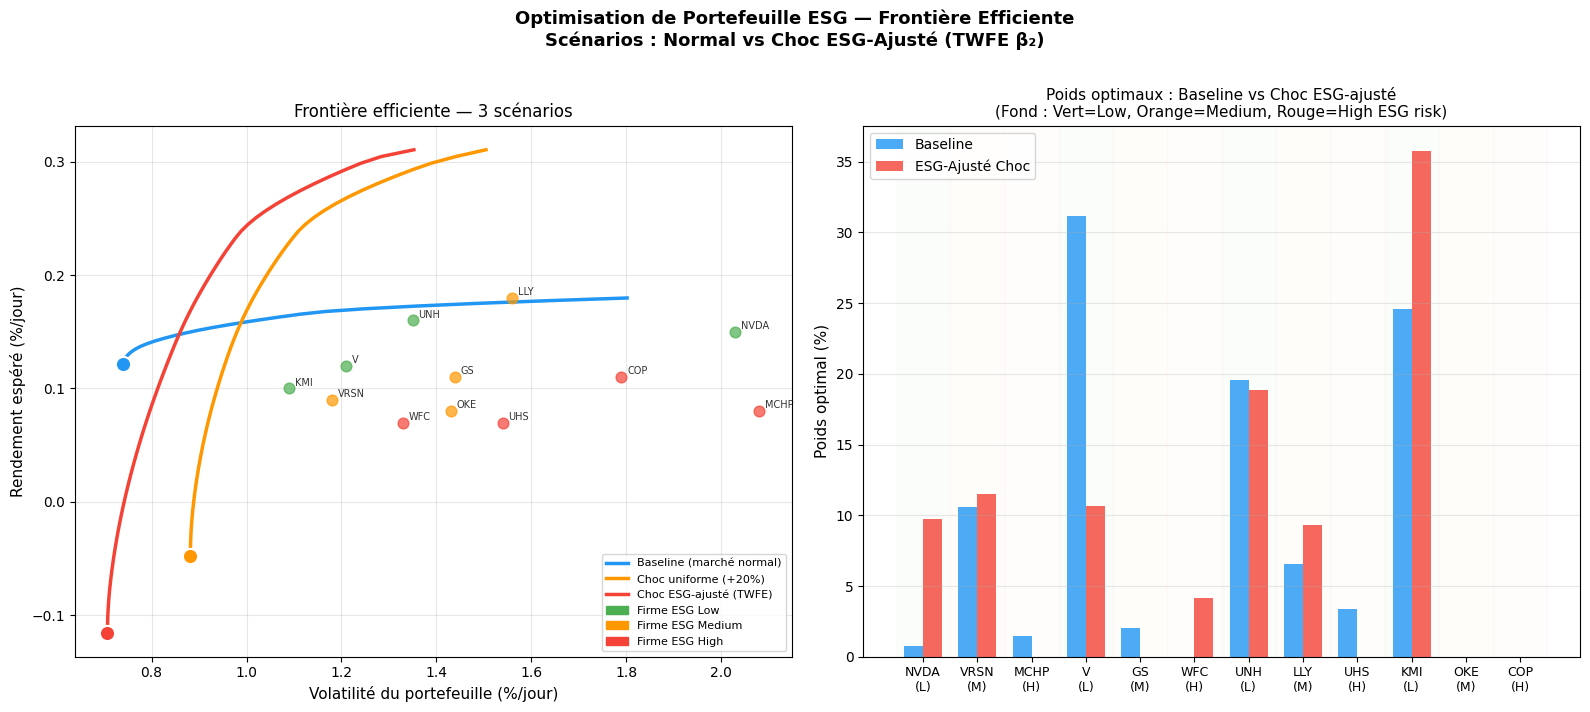

✓ Grafik kaydedildi: /content/portfolio_optimization_figure.png


In [ ]:
# =====================================================================
# HÜCRE 8 — Verimli Sınır (Efficient Frontier) Grafiği
# =====================================================================
def efficient_frontier(cov, mu, n_points=100):
    """Farklı hedef getirilerde min-variance portföyleri hesapla."""
    ret_min = mu.min() * 0.5
    ret_max = mu.max() * 1.5
    targets = np.linspace(ret_min, ret_max, n_points)

    frontier_vols  = []
    frontier_rets  = []

    for r_target in targets:
        res = min_variance_portfolio(cov, mu, target_return=r_target)
        if res.success:
            frontier_vols.append(np.sqrt(portfolio_variance(res.x, cov)) * 100)
            frontier_rets.append(portfolio_return(res.x, mu) * 100)

    return np.array(frontier_vols), np.array(frontier_rets)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Optimisation de Portefeuille ESG — Frontière Efficiente\n"
    "Scénarios : Normal vs Choc ESG-Ajusté (TWFE β₂)",
    fontsize=13, fontweight="bold", y=1.01
)

# ---- Grafik 1: Verimli Sınır Karşılaştırması ----
ax1 = axes[0]
colors_ef = {
    "baseline"     : ("#2196F3", "Baseline (marché normal)"),
    "shock_uniform": ("#FF9800", "Choc uniforme (+20%)"),
    "shock_esg"    : ("#F44336", "Choc ESG-ajusté (TWFE)"),
}

for key, cov_key, mu_key in [
    ("baseline",      COV_BASELINE,     MU_BASE),
    ("shock_uniform", COV_SHOCK_UNIFORM, MU_SHOCK),
    ("shock_esg",     COV_SHOCK_ESG,    MU_SHOCK),
]:
    vols, rets = efficient_frontier(cov_key, mu_key)
    clr, lbl = colors_ef[key]
    ax1.plot(vols, rets, color=clr, linewidth=2.5, label=lbl)

    # Optimal portföy noktası
    opt = opt_results[key]
    ax1.scatter(opt["std"]*100, opt["return"]*100,
                color=clr, s=120, zorder=5, edgecolors="white", linewidth=1.5)

ax1.set_xlabel("Volatilité du portefeuille (%/jour)", fontsize=11)
ax1.set_ylabel("Rendement espéré (%/jour)", fontsize=11)
ax1.set_title("Frontière efficiente — 3 scénarios", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bireysel firmalar
for i, row in firms.iterrows():
    clr_f = {"Low":"#4CAF50","Medium":"#FF9800","High":"#F44336"}[row["esg_level"]]
    ax1.scatter(row["vol_base"]*100, row["ret_mean"]*100,
                color=clr_f, s=60, alpha=0.7, zorder=4)
    ax1.annotate(row["ticker"], (row["vol_base"]*100, row["ret_mean"]*100),
                 textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)
    # Lejant: ESG seviyeleri
patches_esg = [
    mpatches.Patch(color="#4CAF50", label="ESG Low risk"),
    mpatches.Patch(color="#FF9800", label="ESG Medium risk"),
    mpatches.Patch(color="#F44336", label="ESG High risk"),
]
ax1.legend(handles=ax1.lines + patches_esg,
           labels=[colors_ef[k][1] for k in colors_ef] +
                  ["Firme ESG Low","Firme ESG Medium","Firme ESG High"],
           fontsize=8, loc="lower right")

# ---- Grafik 2: Ağırlık Değişimi ----
ax2 = axes[1]
x = np.arange(N)
width = 0.35

bars_base = ax2.bar(x - width/2, w_base * 100, width,
                    label="Baseline", color="#2196F3", alpha=0.8)
bars_esg  = ax2.bar(x + width/2, w_esg  * 100, width,
                    label="ESG-Ajusté Choc", color="#F44336", alpha=0.8)

# ESG seviyesine göre arka plan rengi
esg_color_map = {"Low":"#E8F5E9","Medium":"#FFF3E0","High":"#FFEBEE"}
for i, row in firms.iterrows():
    ax2.axvspan(i - 0.5, i + 0.5, alpha=0.15,
                color=esg_color_map[row["esg_level"]], zorder=0)

ax2.set_xticks(x)
ax2.set_xticklabels(
    [f"{t}\n({lv[0]})" for t, lv in zip(firms["ticker"], firms["esg_level"])],
    fontsize=9
)
ax2.set_ylabel("Poids optimal (%)", fontsize=11)
ax2.set_title("Poids optimaux : Baseline vs Choc ESG-ajusté\n"
              "(Fond : Vert=Low, Orange=Medium, Rouge=High ESG risk)",
              fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()

OUT_FIG = DATA_DIR / "portfolio_optimization_figure.png"
plt.savefig(OUT_FIG, dpi=200, bbox_inches="tight")
plt.show()
print(f"✓ Grafik kaydedildi: {OUT_FIG}")


In [ ]:
# =====================================================================
# HÜCRE 9 — ESG seviyesine göre portföy performans özeti
# =====================================================================
# Her ESG grubundan oluşan eşit ağırlıklı portföy karşılaştırması

esg_groups = ["Low", "Medium", "High"]
group_results = []

for grp in esg_groups:
    idx = firms[firms["esg_level"] == grp].index.tolist()
    n_g = len(idx)

    for scen_name, cov_m, mu_m in [
        ("Baseline",    COV_BASELINE,     MU_BASE),
        ("Choc ESG-aj", COV_SHOCK_ESG,   MU_SHOCK),
    ]:
        w_grp = np.zeros(N)
        w_grp[idx] = 1.0 / n_g

        pvar = portfolio_variance(w_grp, cov_m)
        pret = portfolio_return(w_grp, mu_m)
        group_results.append({
            "ESG Level"   : grp,
            "Scénario"    : scen_name,
            "Volatilité (%/j)": round(np.sqrt(pvar)*100, 4),
            "Rendement (%/j)" : round(pret*100, 4),
            "Sharpe ratio"    : round(pret / np.sqrt(pvar), 3),
        })

grp_df = pd.DataFrame(group_results)
print("\n" + "=" * 65)
print("PERFORMANCE DES PORTEFEUILLES GROUPÉS PAR NIVEAU ESG")
print("=" * 65)
print(grp_df.to_string(index=False))

# Şok döneminde volatilite artışı (%)
print("\nAugmentation de volatilité lors du choc (% relatif) :")
for grp in esg_groups:
    v_base  = grp_df[(grp_df["ESG Level"]==grp) & (grp_df["Scénario"]=="Baseline")]["Volatilité (%/j)"].values[0]
    v_shock = grp_df[(grp_df["ESG Level"]==grp) & (grp_df["Scénario"]=="Choc ESG-aj")]["Volatilité (%/j)"].values[0]
    pct_chg = (v_shock - v_base) / v_base * 100
    print(f"  ESG {grp:6s}: {v_base:.4f}% → {v_shock:.4f}%  (Δ = {pct_chg:+.1f}%)")



PERFORMANCE DES PORTEFEUILLES GROUPÉS PAR NIVEAU ESG
ESG Level    Scénario  Volatilité (%/j)  Rendement (%/j)  Sharpe ratio
      Low    Baseline            1.0165           0.1325         0.130
      Low Choc ESG-aj            0.7945          -0.1860        -0.234
   Medium    Baseline            0.9558           0.1150         0.120
   Medium Choc ESG-aj            0.9098           0.0184         0.020
     High    Baseline            1.2211           0.0825         0.068
     High Choc ESG-aj            1.1844           0.2576         0.218

Augmentation de volatilité lors du choc (% relatif) :
  ESG Low   : 1.0165% → 0.7945%  (Δ = -21.8%)
  ESG Medium: 0.9558% → 0.9098%  (Δ = -4.8%)
  ESG High  : 1.2211% → 1.1844%  (Δ = -3.0%)


In [ ]:
# =====================================================================
# HÜCRE 10 — Tasarım çıktısı: Yatırım kararı kuralları
# =====================================================================
print("\n" + "=" * 70)
print("RÈGLES DE DÉCISION D'INVESTISSEMENT (issu de l'optimisation)")
print("=" * 70)

# Optimal ESG-ayarlı portföyde ağırlığı en yüksek firmalar
top_firms = weight_df.sort_values("w_shock_esg (%)", ascending=False).head(5)
print("\nTop-5 firmes recommandées (scénario choc ESG-ajusté) :")
print(top_firms[["ticker","sector","esg_level","esg_total",
                  "esg_s","w_baseline (%)","w_shock_esg (%)","Δw (pp)"]].to_string(index=False))

# ESG eşik önerisi
opt_esg_avg = (w_esg * firms["esg_s"].values).sum()
print(f"\nESG_S moyen du portefeuille optimal (choc) : {opt_esg_avg:.2f}")
print(f"  → Recommandation : cibler ESG_S < {opt_esg_avg:.1f} pour minimiser")
print(f"    l'amplification de volatilité lors des chocs (β₂ = +0.00135***)")





RÈGLES DE DÉCISION D'INVESTISSEMENT (issu de l'optimisation)

Top-5 firmes recommandées (scénario choc ESG-ajusté) :
ticker  sector esg_level  esg_total  esg_s  w_baseline (%)  w_shock_esg (%)  Δw (pp)
   KMI  Energy       Low       19.0    7.2           24.59            35.76    11.17
   UNH  Health       Low       15.3    9.7           19.60            18.89    -0.71
  VRSN    Tech    Medium       21.3   10.8           10.58            11.52     0.94
     V Finance       Low       16.7    8.2           31.14            10.67   -20.47
  NVDA    Tech       Low       13.6    4.9            0.75             9.75     9.00

ESG_S moyen du portefeuille optimal (choc) : 8.78
  → Recommandation : cibler ESG_S < 8.8 pour minimiser
    l'amplification de volatilité lors des chocs (β₂ = +0.00135***)


In [ ]:
# =====================================================================
# HÜCRE 11 — Excel çıktısı
# =====================================================================
OUT_EXCEL = DATA_DIR / "portfolio_optimization_results.xlsx"

with pd.ExcelWriter(OUT_EXCEL, engine="openpyxl") as writer:
    # Sayfa 1: Firma verileri + ağırlıklar
    weight_df.to_excel(writer, sheet_name="Poids_Optimaux", index=False)

    # Sayfa 2: Senaryo karşılaştırması
    scen_summary = pd.DataFrame([
        {
            "Scénario"       : opt_results[k]["name"],
            "Volatilité (%)" : round(opt_results[k]["std"]*100, 4),
            "Rendement (%)"  : round(opt_results[k]["return"]*100, 4),
            "Sharpe"         : round(opt_results[k]["sharpe"], 3),
        }
        for k in ["baseline","shock_uniform","shock_esg"]
    ])
    scen_summary.to_excel(writer, sheet_name="Scenarios", index=False)

    # Sayfa 3: ESG grup performansı
    grp_df.to_excel(writer, sheet_name="Groupes_ESG", index=False)

    # Sayfa 4: Firma-bazlı şok volatiliteleri
    shock_vol_df = firms[["ticker","sector","esg_level",
                           "esg_total","esg_s","esg_s_z",
                           "vol_base","vol_shock","ret_mean","ret_shock"]].copy()
    shock_vol_df.to_excel(writer, sheet_name="Vol_Choc_Firme", index=False)

print(f"\n✓ Sonuçlar kaydedildi: {OUT_EXCEL}")
print("  Sekmeler: Poids_Optimaux | Scenarios | Groupes_ESG | Vol_Choc_Firme")
print("\n✓ Portföy optimizasyonu tamamlandı.")



✓ Sonuçlar kaydedildi: /content/portfolio_optimization_results.xlsx
  Sekmeler: Poids_Optimaux | Scenarios | Groupes_ESG | Vol_Choc_Firme

✓ Portföy optimizasyonu tamamlandı.
